In [17]:
import numpy as np 
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from scipy.linalg import null_space
from scipy.spatial.distance import cdist
from scipy.optimize import nnls

# Rationale
In off-manifold rehabilitation, I plan to use enslavement patterns during attempted isometric single-finger presses to estimate the residual motor repertoire after stroke. Patients will be then trained to control a 2-dimensional cursor on a screen through multi-finger isometric force patterns. Critically, the decoder that maps the force patterns onto the cursor's position requires force patterns **not** explored by enslavement patterns during single-finger presses, i.e., outside the residual motor repertoire. To validate this approach, in this notebook I leveraged a previous dataset ([Ghavampour et al., 2025](https://journals.physiology.org/doi/full/10.1152/jn.00088.2025)) collected in neurologically intact individuals performing isometric single- and multi-finger flexion/extension configurations (i.e., chords). All possible 242 combinations of isometric flexion/extension are included in the dataset. If the subspace spanned by single-finger enslavement patterns really constrains multi-finger force patterns, as assumed in off-manifold rehabilitation, then even in neurologically intact participants chords that are more distant in the hand control space from single-finger enslavement patterns may be more difficult to perform. To test this hypothesis, I measured the Euclidean and angular distance of each chord from the subspace spanned by single-finger enslavement patterns and then designed a mixed-effect linear model to determine whether these distance metrics captured chord difficulty. 

# Load and prepare data

In [30]:
rng = np.random.default_rng(0)
path = 'data/efc1_all.tsv'
chords = pd.read_csv(os.path.join(path), sep='\t',)
chords = chords[chords.trialCorr==1].reset_index()
chords.MD = pd.to_numeric(chords.MD, errors='coerce')
chords.ET = pd.to_numeric(chords.ET, errors='coerce')

Nf = 5
single_finger = chords[chords.num_fingers==1].copy().reset_index(drop=True)
multi_finger = chords[chords.num_fingers>1].copy().reset_index(drop=True)

col_f = [f'diff_force_f{i + 1}' for i in range(Nf)]

sns = chords.sn.unique()

N = len(sns)

n_perms = 100
n_targets = 100
theta_target = rng.uniform(0, 2 * np.pi, n_targets)
radius = 4.3
pos_target = radius * np.column_stack([np.cos(theta_target), np.sin(theta_target)])

# Helper functions

In [ ]:
def dist_from_subspace(F, B):
    """NNLS residual: how far each row of F is from the non-negative cone spanned by B's rows."""
    return np.array([nnls(B.T, f)[1] for f in F])


def angle_from_subspace(F, B):
    """Angle between F and its closest non-negative combination of B's rows."""
    angles = np.zeros(len(F))
    for i, f in enumerate(F):
        c, res = nnls(B.T, f)
        proj_norm = np.linalg.norm(B.T @ c)
        angles[i] = np.arctan2(res, proj_norm)
    return angles


def angle_between_subspaces(A, B):
    # Orthonormalize
    Q_A, _ = np.linalg.qr(A)
    Q_B, _ = np.linalg.qr(B)
    
    # Trim to actual column count
    Q_A = Q_A[:, :A.shape[1]]
    Q_B = Q_B[:, :B.shape[1]]
    
    # Cross-Gram matrix
    M = Q_A.T @ Q_B
    
    # Singular values → cosines of principal angles
    sigma = np.linalg.svd(M, compute_uv=False)
    sigma = np.clip(sigma, -1, 1)  # guard against floating point
    
    return np.arccos(sigma)  # angles in radians

[32.23062811 80.49251885]


In [62]:
col_dir = [f'direction_{i + 1}' for i in range(5)]
col_eucl = [f'euclidean_{CID}' for CID in single_finger.chordID.unique()]
col_angle = [f'angle_{CID}' for CID in single_finger.chordID.unique()]

multi_finger[col_eucl] = np.nan
multi_finger[col_angle] = np.nan
single_finger[col_dir] = np.nan

sim = pd.DataFrame()

for sn in sns:

    # multi finger
    mask_mf = multi_finger.sn == sn
    F_ch = multi_finger[mask_mf][col_f].to_numpy().astype(float)
    multi_finger.loc[mask_mf, 'magnitude'] = np.linalg.norm(F_ch, axis=1)

    # loop through single-finger conditions
    CIDs = single_finger.chordID.unique()
    B = np.zeros((len(CIDs), Nf))
    var = np.zeros(len(CIDs))

    for c, CID in enumerate(CIDs):

      # single finger
      mask_sf = (single_finger.chordID == CID) & (single_finger.sn == sn)
      F = single_finger[mask_sf][col_f].to_numpy().astype(float)
      F_mean = F.mean(axis=0)

      # fit PCA (for the per-chord reconstruction below)
      pca = PCA(n_components=1)
      pca.fit(F)

      # calc best-fitting line and residuals
      direction = pca.components_[0]
      length = pca.explained_variance_[0]
      centered = F - F_mean
      t = centered @ direction
      recon = F_mean + np.outer(t, direction)
      single_finger.loc[mask_sf, col_dir] = recon

      B[c] = direction
      var[c] = length

      # minimum Euclidean distance from reconstructed patterns along best-fitting line
      dist = cdist(F_ch, recon, metric='euclidean').min(axis=1)
      multi_finger.loc[mask_mf, f'euclidean_{CID}'] = dist

      # angle between each F_ch and this chord's PCA direction
      F_ch_norm = F_ch / np.linalg.norm(F_ch, axis=1, keepdims=True)
      proj  = np.outer(F_ch_norm @ direction, direction)   # component along `direction`
      resid = F_ch_norm - proj                             # orthogonal component
      ang = np.arctan2(np.linalg.norm(resid, axis=1), np.linalg.norm(proj, axis=1))
      multi_finger.loc[mask_mf, f'angle_{CID}'] = ang

    W, _ = np.linalg.qr(rng.standard_normal((Nf * 2, 2)))

    p = np.random.permutation(Nf * 2)

    g = var #[p]
    D_on = (np.diag(g) @ B)

    G = np.eye(Nf)[p[p < Nf]]
    D_off = (np.diag(g) @ B) @ G





In [63]:
D_on

array([[ 0.30057348,  0.02822751,  0.04017031, -0.02009446,  0.01149839],
       [ 0.08215144,  0.0196945 , -0.00490359,  0.02676842, -0.03075815],
       [-0.14343706, -0.00861722,  0.18905298,  0.14803587,  0.0142483 ],
       [ 0.02059924,  0.06951354,  0.20458314,  0.04526492, -0.00196143],
       [-0.02038279, -0.03230936,  0.09746292, -0.04310482, -0.05149247],
       [ 0.04061777,  0.00369564,  0.03803243,  0.01442237,  0.163585  ],
       [-0.18829022, -0.0022583 ,  0.21616425,  0.10740667, -0.07761271],
       [ 0.01903328, -0.0004358 , -0.02558138,  0.00674191,  0.15197875],
       [ 0.12907261,  0.14171354,  0.24459947,  0.06278902,  0.08274343],
       [-0.05600947,  0.32558843,  0.06343522,  0.0198581 , -0.02912423]])

In [64]:
D_off

array([[ 0.02822751,  0.04017031,  0.01149839,  0.30057348, -0.02009446],
       [ 0.0196945 , -0.00490359, -0.03075815,  0.08215144,  0.02676842],
       [-0.00861722,  0.18905298,  0.0142483 , -0.14343706,  0.14803587],
       [ 0.06951354,  0.20458314, -0.00196143,  0.02059924,  0.04526492],
       [-0.03230936,  0.09746292, -0.05149247, -0.02038279, -0.04310482],
       [ 0.00369564,  0.03803243,  0.163585  ,  0.04061777,  0.01442237],
       [-0.0022583 ,  0.21616425, -0.07761271, -0.18829022,  0.10740667],
       [-0.0004358 , -0.02558138,  0.15197875,  0.01903328,  0.00674191],
       [ 0.14171354,  0.24459947,  0.08274343,  0.12907261,  0.06278902],
       [ 0.32558843,  0.06343522, -0.02912423, -0.05600947,  0.0198581 ]])

In [70]:
angle_between_subspaces(D_on, D_off)

array([0.00000000e+00, 1.49011612e-08, 2.10734243e-08, 2.10734243e-08,
       2.98023224e-08])

In [68]:
sim_g = sim.groupby(['sn', 'manifold']).mean(numeric_only=True)

fig, axs = plt.subplots(1, 2, constrained_layout=True)

ax = axs[0]
sb.boxplot(data=sim_g, ax=ax, x='manifold', y='dist', color='grey', )
ax.set_title('Euclidean distance')
ax.set_ylabel('distance (N)')

ax = axs[1]
sb.boxplot(data=sim_g, ax=ax, x='manifold', y='theta',  color='grey',)
ax.set_title('Angle')
ax.set_ylabel('angle (rad)')

fig.suptitle('NNLS distance/angle from single-finger repertoire (simulated on/off)', fontweight='bold')

plt.show()

KeyError: 'sn'

In [22]:
multi_finger['MD_log'] = np.log(multi_finger.MD)
multi_finger['MD_dm'] = multi_finger['MD_log'] - multi_finger.groupby('sn')['MD_log'].transform('mean')
multi_finger['euclidean'] = multi_finger[col_eucl].min(axis=1)
md_eucl = smf.mixedlm("MD_log ~ euclidean", multi_finger, groups=multi_finger['sn']).fit()
md_eucl.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: MD_log     
No. Observations: 62634   Method:             REML       
No. Groups:       14      Scale:              1.0262     
Min. group size:  4377    Log-Likelihood:     -89732.7391
Max. group size:  4635    Converged:          Yes        
Mean group size:  4473.9                                 
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept     -1.908    0.089 -21.325 0.000 -2.084 -1.733
euclidean      0.446    0.004 106.979 0.000  0.437  0.454
Group Var      0.109    0.042                            
=========================================================

"""

In [23]:
multi_finger['angle'] = multi_finger[col_angle].min(axis=1)

md_angle = smf.mixedlm("MD_log ~ angle", multi_finger, groups=multi_finger['sn']).fit()
md_angle.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: MD_log     
No. Observations: 62634   Method:             REML       
No. Groups:       14      Scale:              1.2133     
Min. group size:  4377    Log-Likelihood:     -94973.0083
Max. group size:  4635    Converged:          Yes        
Mean group size:  4473.9                                 
----------------------------------------------------------
           Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept  -0.252     0.087  -2.910  0.004  -0.422  -0.082
angle      -0.119     0.023  -5.182  0.000  -0.165  -0.074
Group Var   0.098     0.035                               
=========================================================

"""

In [24]:
print(multi_finger[['euclidean', 'angle']].corr())

           euclidean     angle
euclidean   1.000000 -0.209382
angle      -0.209382  1.000000


In [25]:
print(multi_finger[['euclidean', 'magnitude']].corr())

           euclidean  magnitude
euclidean   1.000000   0.852767
magnitude   0.852767   1.000000


In [26]:
md_dist = smf.mixedlm("MD_log ~ euclidean + angle", multi_finger, groups=multi_finger['sn']).fit()
md_dist.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: MD_log     
No. Observations: 62634   Method:             REML       
No. Groups:       14      Scale:              1.0220     
Min. group size:  4377    Log-Likelihood:     -89605.5556
Max. group size:  4635    Converged:          Yes        
Mean group size:  4473.9                                 
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept     -2.294    0.092 -24.885 0.000 -2.475 -2.114
euclidean      0.459    0.004 108.263 0.000  0.451  0.468
angle          0.348    0.022  16.147 0.000  0.306  0.391
Group Var      0.108    0.041                            
=========================================================

"""

Text(0.5, 0, 'angle (rad)')

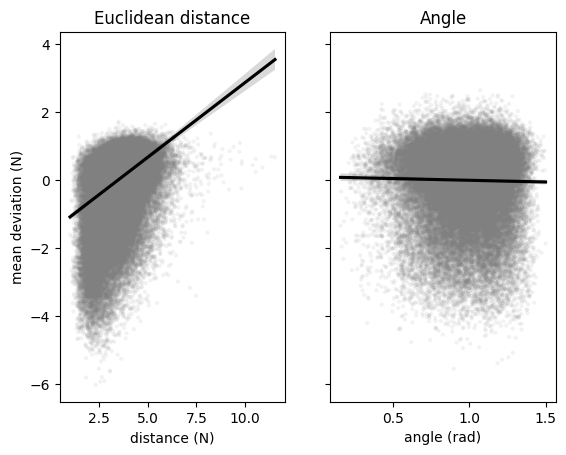

In [27]:
fig, axs = plt.subplots(1, 2, sharey=True)

ax = axs[0]
sb.scatterplot(data=multi_finger, ax=ax, x='euclidean', y='MD_log', alpha=.1, color='grey', edgecolor='none', marker='.')
sb.regplot(data=multi_finger, ax=ax, x='euclidean', y='MD_dm', scatter=False, color='black', units='sn')
ax.set_title('Euclidean distance')
ax.set_xlabel('distance (N)')
ax.set_ylabel('mean deviation (N)')

ax = axs[1]
sb.scatterplot(data=multi_finger, ax=ax, x='angle', y='MD_dm', alpha=.1, color='grey', edgecolor='none', marker='.')
sb.regplot(data=multi_finger, ax=ax, x='angle', y='MD_dm', scatter=False, color='black', units='sn')
ax.set_title('Angle')
ax.set_xlabel('angle (rad)')